**Clone Repository ke Google Colab**

In [60]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Clone repository
%cd /content/drive/MyDrive
!git clone https://github.com/bumblebee14/pertemuan5-tugas-svm-naivebayes.git
%cd pertemuan5-tugas-svm-naivebayes

# Cek status
!git status


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive
fatal: destination path 'pertemuan5-tugas-svm-naivebayes' already exists and is not an empty directory.
/content/drive/MyDrive/pertemuan5-tugas-svm-naivebayes
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


**Import Library & Persiapan Data**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score)
from sklearn.pipeline import Pipeline

import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print("Library berhasil diimport!")


Library berhasil diimport!


**Membuat Dataset Teks**

In [8]:
data = {
    'komentar': [
        # POSITIF (14)
        "Alhamdulillah, ceramahnya sangat bermanfaat",
        "Materi ini mencerahkan hati saya",
        "Terima kasih ustadz, ilmunya sangat berguna",
        "Saya suka cara penyampaiannya yang santun",
        "Semoga Allah membalas kebaikan ustadz",
        "Ini ceramah terbaik yang pernah saya dengar",
        "Materinya dalam dan mudah dipahami",
        "Sangat menginspirasi, semoga istiqomah",
        "Kajiannya rutin saya ikuti, selalu bermanfaat",
        "Penyampaiannya jelas dan tidak membosankan",
        "Ustadznya ramah dan ilmunya luas",
        "Saya jadi lebih semangat beribadah",
        "Penjelasannya runut dan sistematis",
        "Semoga menjadi amal jariyah",
        # NEGATIF (13)
        "Ceramahnya terlalu panjang dan membosankan",
        "Materinya tidak sesuai dengan tema",
        "Saya tidak paham dengan penjelasannya",
        "Suaranya kurang jelas, sulit didengar",
        "Terlalu banyak basa-basi, tidak fokus",
        "Kontennya tidak relevan dengan kebutuhan saya",
        "Saya kecewa dengan penyampaiannya",
        "Materinya dangkal dan tidak mendalam",
        "Waktunya terlalu lama, membuat ngantuk",
        "Tidak ada contoh praktis, hanya teori",
        "Bahasa yang digunakan terlalu rumit",
        "Jadwalnya sering molor, tidak disiplin",
        "Audio sering terputus, mengganggu",
        # NETRAL (13)
        "Ceramahnya cukup, tidak terlalu istimewa",
        "Materinya standar seperti kajian lain",
        "Saya ikut karena teman, bukan karena tertarik",
        "Penyampaiannya biasa saja",
        "Topiknya sedang trending, jadi saya tonton",
        "Tidak ada yang baru, tapi tidak buruk juga",
        "Cukup informatif, tapi tidak mengesankan",
        "Saya baru pertama kali ikut kajian ini",
        "Durasi waktunya standar",
        "Tempatnya nyaman, tapi materinya biasa",
        "Saya tidak terlalu fokus karena sambil kerja",
        "Bisa jadi referensi, tapi belum tentu saya ikuti lagi",
        "Netral saja, tidak ada komentar khusus"
    ],
    'sentimen': (
        ['positif'] * 14 +
        ['negatif'] * 13 +
        ['netral'] * 13
    )
}

df = pd.DataFrame(data)


print("INFORMASI DATASET")

print(f"Jumlah data    : {len(df)}")
print(f"Jumlah kelas   : {df['sentimen'].nunique()}")
print(f"Kelas          : {list(df['sentimen'].unique())}")
print("\nDistribusi kelas:")
print(df['sentimen'].value_counts().to_string())
print("\nContoh data:")
print(df.head(5).to_string(index=False))


INFORMASI DATASET
Jumlah data    : 40
Jumlah kelas   : 3
Kelas          : ['positif', 'negatif', 'netral']

Distribusi kelas:
sentimen
positif    14
negatif    13
netral     13

Contoh data:
                                   komentar sentimen
Alhamdulillah, ceramahnya sangat bermanfaat  positif
           Materi ini mencerahkan hati saya  positif
Terima kasih ustadz, ilmunya sangat berguna  positif
  Saya suka cara penyampaiannya yang santun  positif
      Semoga Allah membalas kebaikan ustadz  positif


**EDA (Distribusi Kelas, Panjang Teks, Word Cloud)**

------------------------------------------------------------
EDA: Distribusi Kelas
------------------------------------------------------------


/tmp/ipykernel_2287/257220412.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentimen', data=df, palette='Set2')


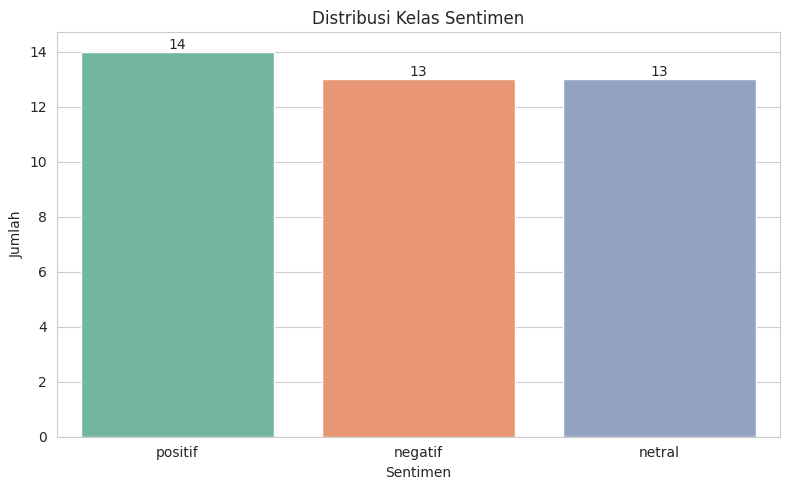


------------------------------------------------------------
EDA: Panjang Teks
------------------------------------------------------------


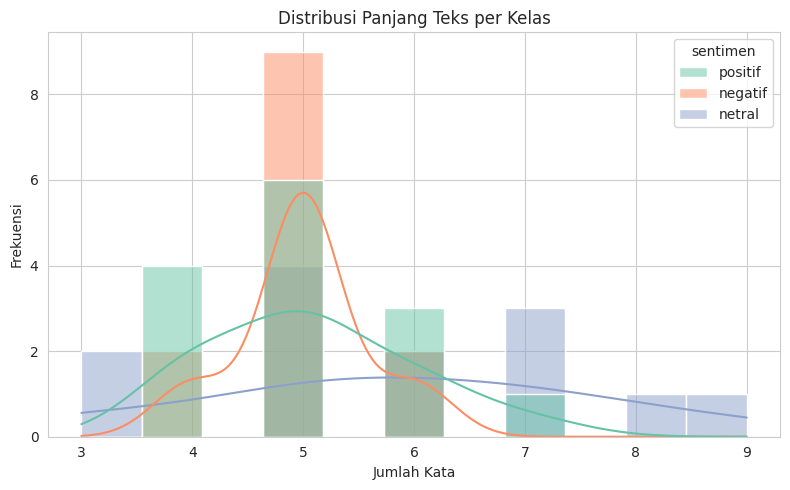


------------------------------------------------------------
EDA: Word Cloud Per Kelas
------------------------------------------------------------


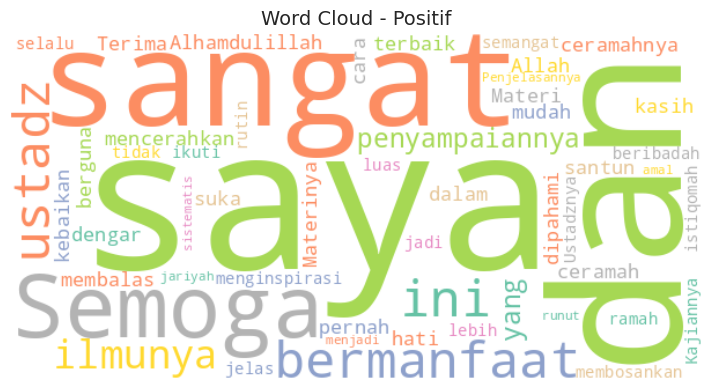

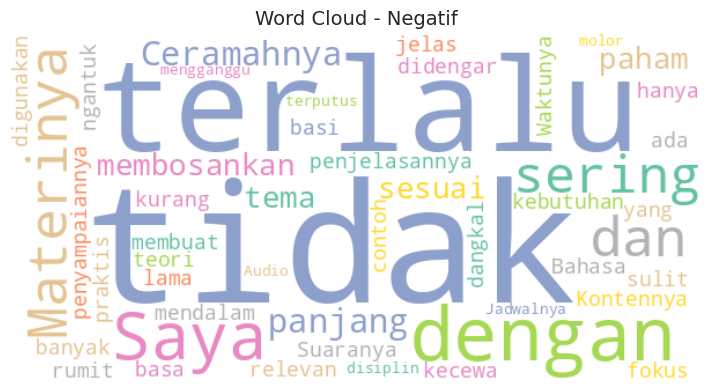

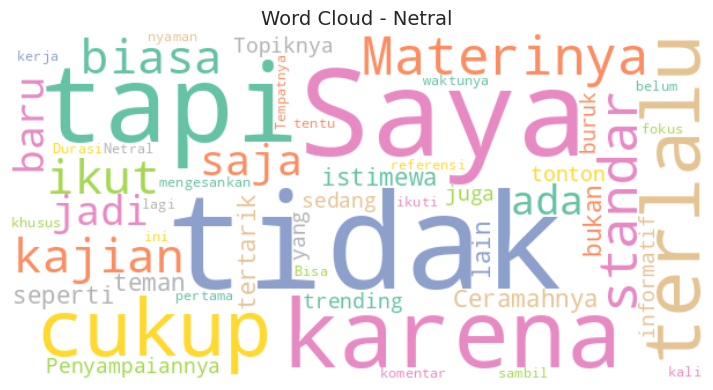

In [16]:
print("-" * 60)
print("EDA: Distribusi Kelas")
print("-" * 60)

# 1. Distribusi kelas (vertikal)
plt.figure(figsize=(8, 5))
sns.countplot(x='sentimen', data=df, palette='Set2')
plt.title('Distribusi Kelas Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='bottom')
plt.tight_layout()
plt.show()

print("\n" + "-" * 60)
print("EDA: Panjang Teks")
print("-" * 60)

# 2. Panjang teks (vertikal)
df['panjang'] = df['komentar'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='panjang', hue='sentimen', kde=True, palette='Set2')
plt.title('Distribusi Panjang Teks per Kelas')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

print("\n" + "-" * 60)
print("EDA: Word Cloud Per Kelas")
print("-" * 60)

# 3. Word Cloud per kelas (vertikal, satu per satu)
for label in ['positif', 'negatif', 'netral']:
    text = ' '.join(df[df['sentimen'] == label]['komentar'])
    wc = WordCloud(width=600, height=300,
                   background_color='white',
                   colormap='Set2').generate(text)
    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud - {label.capitalize()}', fontsize=14)
    plt.tight_layout()
    plt.show()


**Preprocessing Teks**

In [20]:
stop_words = set(stopwords.words('indonesian'))

def preprocess(text):
    """Case folding, hapus non-alfabet, tokenisasi, stopword removal."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    return ' '.join(tokens)

df['bersih'] = df['komentar'].apply(preprocess)

print("-" * 60)
print("HASIL PREPROCESSING")
print("-" * 60)
print(f"Jumlah stopword Bahasa Indonesia: {len(stop_words)}")
print("\nContoh hasil preprocessing:")
print("-" * 60)
for i in range(5):
    print(f"Asli   : {df['komentar'][i]}")
    print(f"Bersih : {df['bersih'][i]}")
    print("-" * 60)


------------------------------------------------------------
HASIL PREPROCESSING
------------------------------------------------------------
Jumlah stopword Bahasa Indonesia: 757

Contoh hasil preprocessing:
------------------------------------------------------------
Asli   : Alhamdulillah, ceramahnya sangat bermanfaat
Bersih : alhamdulillah ceramahnya bermanfaat
------------------------------------------------------------
Asli   : Materi ini mencerahkan hati saya
Bersih : materi mencerahkan hati
------------------------------------------------------------
Asli   : Terima kasih ustadz, ilmunya sangat berguna
Bersih : terima kasih ustadz ilmunya berguna
------------------------------------------------------------
Asli   : Saya suka cara penyampaiannya yang santun
Bersih : suka penyampaiannya santun
------------------------------------------------------------
Asli   : Semoga Allah membalas kebaikan ustadz
Bersih : semoga allah membalas kebaikan ustadz
----------------------------------

**Implementasi Naïve Bayes from Scratch (Multinomial + Laplace)**

In [31]:
class NaiveBayesScratch:
    """Naïve Bayes Multinomial dengan Laplace smoothing."""
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes = None
        self.prior = {}
        self.likelihood = {}

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples = X.shape[0]
        for c in self.classes:
            self.prior[c] = np.sum(y == c) / n_samples
        for c in self.classes:
            X_c = X[y == c]
            count = np.sum(X_c, axis=0)
            self.likelihood[c] = (count + self.alpha) / (len(X_c) + 2 * self.alpha)

    def predict(self, X):
        preds = []
        for x in X:
            posteriors = {}
            for c in self.classes:
                logp = np.log(self.prior[c])
                for i, xi in enumerate(x):
                    if xi > 0:
                        logp += xi * np.log(self.likelihood[c][i])
                posteriors[c] = logp
            preds.append(max(posteriors, key=posteriors.get))
        return np.array(preds)

# Vectorize
vec = CountVectorizer()
X_counts = vec.fit_transform(df['bersih']).toarray()
y = df['sentimen'].values

print("INFORMASI FITUR")
print("-" * 50)
print(f"Jumlah fitur (kata unik): {X_counts.shape[1]}")
print(f"Contoh vocabulary       : {list(vec.vocabulary_.keys())[:10]}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_counts, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nData train: {X_train.shape[0]} | Data test: {X_test.shape[0]}")

# Bandingkan alpha
print("\n" + "-" * 50)
print("PERBANDINGAN ALPHA - NAÏVE BAYES FROM SCRATCH")
print("-" * 50)
print(f"{'Alpha':<10}{'Accuracy':<12}{'F1-Score':<12}")
for alpha in [0.01, 0.1, 1.0, 2.0]:
    nb = NaiveBayesScratch(alpha=alpha)
    nb.fit(X_train, y_train)
    y_pred = nb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"{alpha:<10}{acc:<12.4f}{f1:<12.4f}")


INFORMASI FITUR
--------------------------------------------------
Jumlah fitur (kata unik): 86
Contoh vocabulary       : ['alhamdulillah', 'ceramahnya', 'bermanfaat', 'materi', 'mencerahkan', 'hati', 'terima', 'kasih', 'ustadz', 'ilmunya']

Data train: 32 | Data test: 8

--------------------------------------------------
PERBANDINGAN ALPHA - NAÏVE BAYES FROM SCRATCH
--------------------------------------------------
Alpha     Accuracy    F1-Score    
0.01      0.3750      0.2917      
0.1       0.3750      0.2917      
1.0       0.3750      0.2917      
2.0       0.3750      0.2917      


**Implementasi Library (NB & SVM)
python**

In [30]:
models = {
    'NB Multinomial': MultinomialNB(),
    'NB Bernoulli'  : BernoulliNB(),
    'SVM Linear'    : SVC(kernel='linear', probability=True, random_state=42),
    'SVM RBF'       : SVC(kernel='rbf', probability=True, random_state=42),
    'SVM Polynomial': SVC(kernel='poly', degree=3, probability=True, random_state=42)
}

hasil = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    hasil.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

df_hasil = pd.DataFrame(hasil).sort_values('F1-Score', ascending=False)

print("PERBANDINGAN PERFORMA SEMUA MODEL")
print("-" * 55)
print(df_hasil.to_string(index=False))


PERBANDINGAN PERFORMA SEMUA MODEL
-------------------------------------------------------
         Model  Accuracy  Precision  Recall  F1-Score
NB Multinomial      0.25   0.071429    0.25  0.111111
  NB Bernoulli      0.25   0.071429    0.25  0.111111
    SVM Linear      0.25   0.071429    0.25  0.111111
       SVM RBF      0.25   0.062500    0.25  0.100000
SVM Polynomial      0.25   0.062500    0.25  0.100000


**Feature Extraction (Count vs TF-IDF)**

In [28]:
print("PERBANDINGAN FEATURE EXTRACTION")
print("-" * 60)
print(f"{'Vectorizer':<15}{'Model':<20}{'Accuracy':<12}{'F1-Score':<12}")
print("-" * 60)

for vec_name, vectorizer in [('Count', CountVectorizer()),
                              ('TF-IDF', TfidfVectorizer())]:
    for clf_name, clf in [('MultinomialNB', MultinomialNB()),
                          ('SVM Linear', SVC(kernel='linear', random_state=42))]:
        pipe = Pipeline([('vec', vectorizer), ('clf', clf)])
        pipe.fit(df['bersih'], y)
        y_pred = pipe.predict(df['bersih'])
        acc = accuracy_score(y, y_pred)
        f1 = f1_score(y, y_pred, average='weighted')
        print(f"{vec_name:<15}{clf_name:<20}{acc:<12.4f}{f1:<12.4f}")


PERBANDINGAN FEATURE EXTRACTION
------------------------------------------------------------
Vectorizer     Model               Accuracy    F1-Score    
------------------------------------------------------------
Count          MultinomialNB       0.9750      0.9749      
Count          SVM Linear          0.9750      0.9749      
TF-IDF         MultinomialNB       0.9750      0.9749      
TF-IDF         SVM Linear          0.9750      0.9749      


**Hyperparameter Tuning (GridSearchCV)**

In [32]:
print("-" * 70)
print("GRIDSEARCH SVM")
print("-" * 70)

param_svm = {
    'C'     : [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma' : ['scale', 'auto']
}
grid_svm = GridSearchCV(SVC(probability=True, random_state=42),
                        param_svm, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_svm.fit(X_train, y_train)
print(f"Best Parameters : {grid_svm.best_params_}")
print(f"Best CV Score   : {grid_svm.best_score_:.4f}")

print("\n" + "-" * 70)
print("GRIDSEARCH NAÏVE BAYES")
print("-" * 70)

param_nb = {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}
grid_nb = GridSearchCV(MultinomialNB(), param_nb,
                       cv=5, scoring='f1_weighted', n_jobs=-1)
grid_nb.fit(X_train, y_train)
print(f"Best Parameters : {grid_nb.best_params_}")
print(f"Best CV Score   : {grid_nb.best_score_:.4f}")


----------------------------------------------------------------------
GRIDSEARCH SVM
----------------------------------------------------------------------
Best Parameters : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score   : 0.4690

----------------------------------------------------------------------
GRIDSEARCH NAÏVE BAYES
----------------------------------------------------------------------
Best Parameters : {'alpha': 0.01}
Best CV Score   : 0.3781


**Evaluasi Lengkap (CM, ROC-AUC, CV)**

CONFUSION MATRIX - SVM TERBAIK
--------------------------------------------------


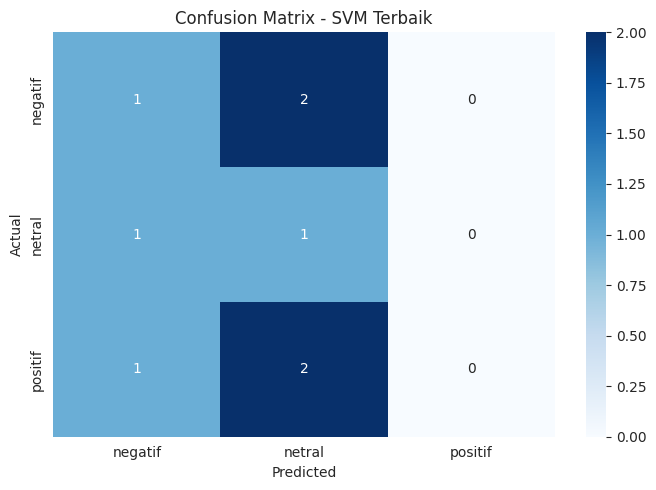


------------------------------------------------------------
CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

     negatif       0.33      0.33      0.33         3
      netral       0.20      0.50      0.29         2
     positif       0.00      0.00      0.00         3

    accuracy                           0.25         8
   macro avg       0.18      0.28      0.21         8
weighted avg       0.17      0.25      0.20         8

CROSS-VALIDATION 5-FOLD
------------------------------------------------------------
F1 per fold : ['0.4813', '0.4062', '0.5333', '0.5000', '0.2333']
Rata-rata   : 0.4308
Std Deviasi : 0.1072


In [38]:
y_pred_best = grid_svm.best_estimator_.predict(X_test)

print("CONFUSION MATRIX - SVM TERBAIK")
print("-" * 50)

cm = confusion_matrix(y_test, y_pred_best,
                      labels=['negatif', 'netral', 'positif'])
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negatif', 'netral', 'positif'],
            yticklabels=['negatif', 'netral', 'positif'])
plt.title('Confusion Matrix - SVM Terbaik')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\n" + "-" * 60)
print("CLASSIFICATION REPORT")
print("-" * 60)
print(classification_report(y_test, y_pred_best, zero_division=0))

print("CROSS-VALIDATION 5-FOLD")
print("-" * 60)
cv_scores = cross_val_score(grid_svm.best_estimator_, X_counts, y,
                            cv=5, scoring='f1_weighted')
print(f"F1 per fold : {[f'{s:.4f}' for s in cv_scores]}")
print(f"Rata-rata   : {cv_scores.mean():.4f}")
print(f"Std Deviasi : {cv_scores.std():.4f}")


**Analisis Feature Importance**

TOP 10 KATA PALING INDIKATIF PER KELAS

Kelas 'NEGATIF':
----------------------------------------
   1. materinya
   2. suaranya
   3. sulit
   4. tema
   5. teori
   6. sesuai
   7. jadwalnya
   8. penjelasannya
   9. membosankan
  10. mengganggu

Kelas 'NETRAL':
----------------------------------------
   1. standar
   2. materinya
   3. kajian
   4. tertarik
   5. tonton
   6. topiknya
   7. tempatnya
   8. kali
   9. istimewa
  10. informatif

Kelas 'POSITIF':
----------------------------------------
   1. semoga
   2. ustadz
   3. ilmunya
   4. bermanfaat
   5. penyampaiannya
   6. terbaik
   7. sistematis
   8. semangat
   9. santun
  10. materinya


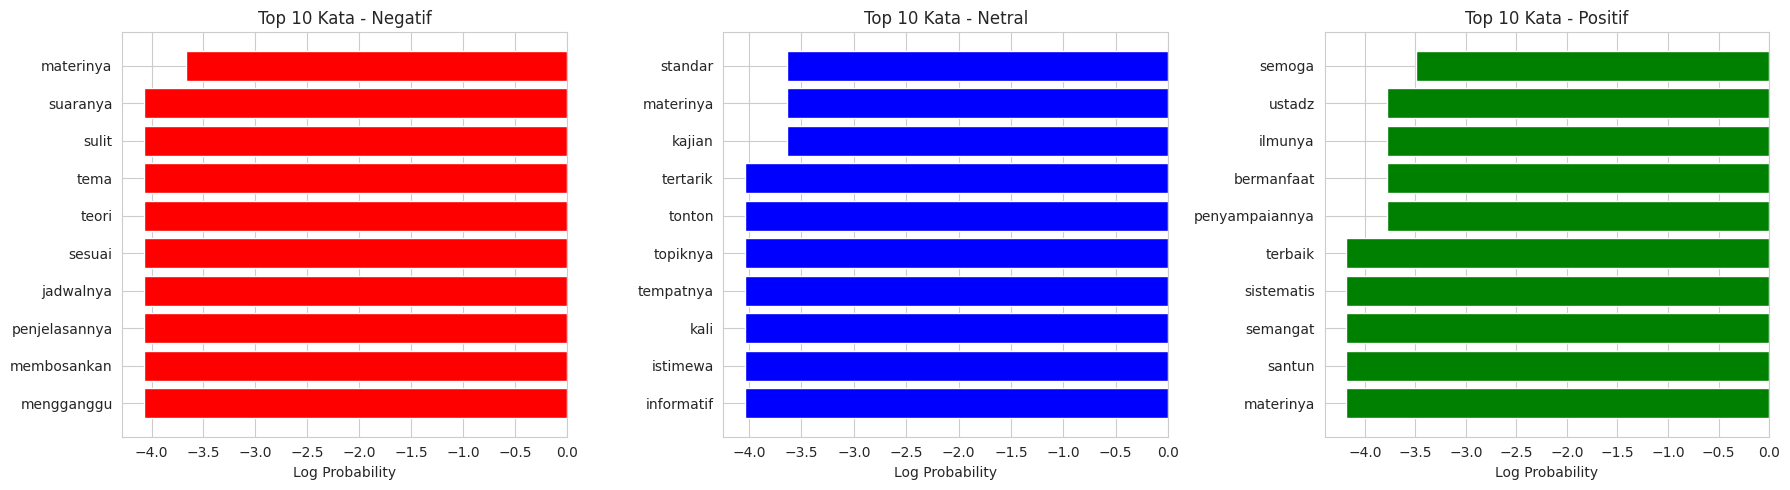

In [42]:
vec_final = CountVectorizer()
X_final = vec_final.fit_transform(df['bersih'])
nb_final = MultinomialNB().fit(X_final, y)
feature_names = vec_final.get_feature_names_out()

print("TOP 10 KATA PALING INDIKATIF PER KELAS")

for i, label in enumerate(nb_final.classes_):
    top = np.argsort(nb_final.feature_log_prob_[i])[-10:][::-1]
    print(f"\nKelas '{label.upper()}':")
    print("-" * 40)
    for rank, idx in enumerate(top, 1):
        print(f"  {rank:2d}. {feature_names[idx]}")

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'positif': 'green', 'negatif': 'red', 'netral': 'blue'}

for ax, (i, label) in zip(axes, enumerate(nb_final.classes_)):
    top = np.argsort(nb_final.feature_log_prob_[i])[-10:][::-1]
    words = [feature_names[idx] for idx in top]
    probs = [nb_final.feature_log_prob_[i][idx] for idx in top]
    ax.barh(words[::-1], probs[::-1], color=colors[label])
    ax.set_title(f'Top 10 Kata - {label.capitalize()}')
    ax.set_xlabel('Log Probability')

plt.tight_layout()
plt.show()


**Analisis Error**

In [49]:
print("ANALISIS ERROR - SVM TERBAIK")
print("-" * 30)

errors = y_test != y_pred_best
error_indices = np.where(errors)[0]

print(f"Total error  : {len(error_indices)} dari {len(y_test)} data")
print(f"Error rate   : {len(error_indices)/len(y_test)*100:.2f}%")

if len(error_indices) > 0:
    print("\nContoh kesalahan prediksi:")
    for i, idx in enumerate(error_indices[:5], 1):
        print(f"{i}. Aktual   : {y_test[idx].upper()}")
        print(f"   Prediksi : {y_pred_best[idx].upper()}")
else:
    print("\nTidak ada kesalahan prediksi pada data test.")


ANALISIS ERROR - SVM TERBAIK
------------------------------
Total error  : 6 dari 8 data
Error rate   : 75.00%

Contoh kesalahan prediksi:
1. Aktual   : NEGATIF
   Prediksi : NETRAL
2. Aktual   : POSITIF
   Prediksi : NEGATIF
3. Aktual   : NETRAL
   Prediksi : NEGATIF
4. Aktual   : POSITIF
   Prediksi : NETRAL
5. Aktual   : NEGATIF
   Prediksi : NETRAL


**Commit & Push ke GitHub**

In [83]:
!git add .
!git commit -m "feat: pipeline klasifikasi teks SVM & Naive Bayes lengkap"
!git push origin main


[main b774bac] feat: pipeline klasifikasi teks SVM & Naive Bayes lengkap
 1 file changed, 1 insertion(+), 1 deletion(-)
fatal: could not read Username for 'https://github.com': No such device or address
